In [1]:
"""
Model_tester.py
===============
Clean testing / evaluation script for Prism spectral emulators.

Tests included:
  1. Reduced chi-squared (χ²_red) — overall and binned by Teff, log g, [M/H], SNR
  2. Information leakage test — using apogee_mask.npy (full test set, all baselines)
  3. Reduced chi-squared by stellar type — cool giants, sun-like dwarfs, hot stars
"""

# ── Imports ──────────────────────────────────────────────────────────────
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras import layers, models, Input, regularizers
from sklearn.experimental import enable_iterative_imputer      # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from scipy.stats import binned_statistic, spearmanr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

# ── Configuration ────────────────────────────────────────────────────────
class Config:
    # --- Paths ---
    H5_PATH    = "/kaggle/input/datasets/aneeshshastri/aspcapstar-dr17-150kstars/apogee_dr17_parallel.h5"
    TFREC_DIR  = "/kaggle/working/tfrecords"
    STATS_PATH = "/kaggle/working/dataset_stats.npz"

    # --- Test-set range (stars beyond training + validation) ---
    # Training: 0 → 120,000   |   Validation: 120,000 → 140,000
    # Test:     140,000 → end of file
    TEST_START = 140_000

    # --- System ---
    RANDOM_SEED = 42

    # --- Model Hyperparameters ---
    BATCH_SIZE    = 64
    LEARNING_RATE = 1e-3
    EPOCHS        = 50
    LATENT_DIM    = 268
    OUTPUT_LENGTH = 8575

    # --- Loss related ---
    IVAR_SCALE   = 1000.0
    CLIP_NORM    = 1.0
    BADPIX_CUTOFF = 1e-3

    # --- Predictor labels ---
    # CAUTION: Order matters — everything follows this order.
    SELECTED_LABELS = [
        # 1. Core
        'TEFF', 'LOGG', 'M_H', 'VMICRO', 'VMACRO', 'VSINI',
        # 2. CNO
        'C_FE', 'N_FE', 'O_FE',
        # 3. Metals
        'FE_H',
        'MG_FE', 'SI_FE', 'CA_FE', 'TI_FE', 'S_FE',
        'AL_FE', 'MN_FE', 'NI_FE', 'CR_FE', 'K_FE',
        'NA_FE', 'V_FE', 'CO_FE',
    ]

    ABUNDANCE_INDICES = [i for i, label in enumerate(SELECTED_LABELS) if '_FE' in label]
    FE_H_INDEX = SELECTED_LABELS.index('FE_H')
    N_LABELS   = len(SELECTED_LABELS) + 4
    ERRORS     = [f'{label}_ERR' for label in SELECTED_LABELS]

    # --- Wavelength grid ---
    WAVELENGTH_START = 1514
    WAVELENGTH_END   = 1694


config = Config()
np.random.seed(config.RANDOM_SEED)
tf.random.set_seed(config.RANDOM_SEED)

2026-04-05 19:36:36.001723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775417796.190481      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775417796.241220      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775417796.667740      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775417796.667780      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775417796.667782      24 computation_placer.cc:177] computation placer alr

In [2]:
def get_nans(h5_path, selected_labels):
    """
    Scans the dataset and prints the percentage of unusable (NaN/Flagged) 
    data for each label.
    """
    print(f"Scanning {len(selected_labels)} labels for missing data...")
    print(f"{'LABEL':<10} | {'MISSING %':<10} | {'STATUS'}")
    
    missing_report = {}
    
    with h5py.File(h5_path, 'r') as f:
        # Detect structure (Group vs Table)
        if isinstance(f['metadata'], h5py.Group):
            get_col = lambda k: f['metadata'][k][:]
            keys = list(f['metadata'].keys())
        else:
            get_col = lambda k: f['metadata'][k]
            keys = f['metadata'].dtype.names

        # Get total count from the first label
        total_stars = len(get_col(selected_labels[0]))
        
        for label in selected_labels:
            # 1. Get Raw Values
            raw_vals = get_col(label)
            
            # 2. Check Flags (The Robust Logic)
            flag_name = f"{label}_FLAG"
            if flag_name in keys:
                flg = get_col(flag_name)
                # Handle Void/Structured types
                if flg.dtype.names: flg = flg[flg.dtype.names[0]]
                if flg.dtype.kind == 'V': flg = flg.view('<i4')
                
                # Bad if Flag != 0
                is_bad_flag = (flg.astype(int) != 0)
            else:
                is_bad_flag = np.zeros(total_stars, dtype=bool)
                
            # 3. Check Placeholder Values (Standard APOGEE -9999)
            # We check < -100 to catch any weird negative placeholders
            is_bad_val = (raw_vals < -100)
            
            # 4. Combine (Either Flagged OR Missing Value)
            total_bad = np.logical_or(is_bad_flag, is_bad_val)
            
            # 5. Calculate Stats
            bad_count = np.sum(total_bad)
            pct = (bad_count / total_stars) * 100
            missing_report[label] = pct
            
            # 6. Status Indicator
            if pct < 5.0:
                status = "Great"
            elif pct < 20.0:
                status = "Okay"
            else:
                status = "Hell Nah"
            
            print(f"{label:<10} | {pct:>9.2f}% | {status}")

    print("-" * 50)
    return missing_report
get_nans(config.H5_PATH,config.SELECTED_LABELS)

Scanning 23 labels for missing data...
LABEL      | MISSING %  | STATUS
TEFF       |      0.00% | Great
LOGG       |      0.00% | Great
M_H        |      0.00% | Great
VMICRO     |      0.00% | Great
VMACRO     |      0.00% | Great
VSINI      |      0.00% | Great
C_FE       |      0.55% | Great
N_FE       |     10.34% | Okay
O_FE       |      0.50% | Great
FE_H       |      0.47% | Great
MG_FE      |      0.47% | Great
SI_FE      |      0.46% | Great
CA_FE      |      1.01% | Great
TI_FE      |     10.14% | Okay
S_FE       |      5.17% | Okay
AL_FE      |      4.91% | Great
MN_FE      |      8.29% | Okay
NI_FE      |      2.05% | Great
CR_FE      |      5.18% | Okay
K_FE       |      3.24% | Great
NA_FE      |      4.33% | Great
V_FE       |      2.51% | Great
CO_FE      |     13.81% | Okay
--------------------------------------------------


{'TEFF': np.float64(0.0),
 'LOGG': np.float64(0.0),
 'M_H': np.float64(0.0),
 'VMICRO': np.float64(0.0),
 'VMACRO': np.float64(0.0),
 'VSINI': np.float64(0.0),
 'C_FE': np.float64(0.5527919661790006),
 'N_FE': np.float64(10.338343357827775),
 'O_FE': np.float64(0.4987797234039716),
 'FE_H': np.float64(0.4661056506141392),
 'MG_FE': np.float64(0.4661056506141392),
 'SI_FE': np.float64(0.4614379259298774),
 'CA_FE': np.float64(1.0135630742968407),
 'TI_FE': np.float64(10.136297560780443),
 'S_FE': np.float64(5.167171225477775),
 'AL_FE': np.float64(4.908445914407265),
 'MN_FE': np.float64(8.294546763933159),
 'NI_FE': np.float64(2.049797954202953),
 'CR_FE': np.float64(5.179840763906485),
 'K_FE': np.float64(3.2374004774415535),
 'NA_FE': np.float64(4.334982596055106),
 'V_FE': np.float64(2.5099022445087553),
 'CO_FE': np.float64(13.809796887294453)}

In [3]:
# ============================================================================
#  CUSTOM KERAS LAYERS (required for model loading)
# ============================================================================

@tf.keras.utils.register_keras_serializable()
class ColumnSelector(layers.Layer):
    """Selects specific columns from the input."""
    def __init__(self, indices, **kwargs):
        super().__init__(**kwargs)
        self.indices = list(indices)

    def call(self, inputs):
        return tf.gather(inputs, self.indices, axis=1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'indices': self.indices})
        return cfg


@tf.keras.utils.register_keras_serializable()
class BeerLambertLaw(layers.Layer):
    """Applies the Beer-Lambert law: Flux = k * exp(-Tau)."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, k, tau):
        return k * tf.math.exp(-tau)


@tf.keras.utils.register_keras_serializable()
class GetAbundances(layers.Layer):
    """Slices a single column from the input."""
    def __init__(self, col_id, **kwargs):
        super().__init__(**kwargs)
        self.index = col_id

    def call(self, inputs):
        return inputs[:, self.index : self.index + 1]
        
@tf.keras.utils.register_keras_serializable()
class SparseProjector(tf.keras.layers.Layer):
    def __init__(self, active_indices, weights, total_pixels, label_name="unknown", **kwargs):
        # Override name before passing to super to avoid conflict in from_config
        kwargs['name'] = f"Sparse_Projector_{label_name}"
        super().__init__(**kwargs)
        self.total_pixels = total_pixels
        self.label_name = label_name
        self.active_indices = tf.constant(active_indices, dtype=tf.int32)
        self.weights_tensor = tf.constant(weights, dtype=tf.float32)

    def call(self, local_tau):
        input_dtype = local_tau.dtype
        local_tau_32 = tf.cast(local_tau, tf.float32)
        weighted = local_tau_32 * self.weights_tensor[None, :]

        batch_size = tf.shape(local_tau)[0]
        n_active = tf.shape(self.active_indices)[0]

        batch_ids = tf.repeat(tf.range(batch_size), n_active)
        pixel_ids = tf.tile(self.active_indices, tf.expand_dims(batch_size, axis=0))

        scatter_idx = tf.stack([batch_ids, pixel_ids], axis=-1)
        flat_weighted = tf.reshape(weighted, [-1])

        full = tf.scatter_nd(
            scatter_idx,
            flat_weighted,
            shape=tf.stack([batch_size, tf.constant(self.total_pixels, dtype=tf.int32)])
        )
        # Cast back to original input dtype
        return tf.cast(full, input_dtype)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.total_pixels)

    def get_config(self):
        config = super().get_config()
        config.update({
            'active_indices': self.active_indices.numpy().tolist(),
            'weights': self.weights_tensor.numpy().tolist(),
            'total_pixels': self.total_pixels,
            'label_name': self.label_name,
        })
        return config

    @classmethod
    def from_config(cls, config):
        config['active_indices'] = np.array(config['active_indices'], dtype=np.int32)
        config['weights'] = np.array(config['weights'], dtype=np.float32)
        config.pop('name', None)  # remove saved name, __init__ constructs it from label_name
        return cls(**config)

# ============================================================================
#  CUSTOM LOSS / METRIC FUNCTIONS (required for model loading)
# ============================================================================

@register_keras_serializable()
def chi2_estimate(y_true, y_pred):
    """Quick per-batch χ² estimate used as a Keras metric."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    if len(y_pred.shape) == 2:
        y_pred = tf.expand_dims(y_pred, -1)
    real_flux  = y_true[:, :, 0:1]
    ivar       = y_true[:, :, 1:2]
    valid_mask = tf.cast(real_flux > config.BADPIX_CUTOFF, tf.float32)
    safe_flux  = tf.where(valid_mask == 1.0, real_flux, y_pred)
    weight     = tf.where(ivar > 0, ivar, 0.0)
    wmse_term  = tf.square(safe_flux - y_pred) * weight * valid_mask
    n_valid    = tf.reduce_sum(valid_mask, 1)
    n_params   = len(config.SELECTED_LABELS)
    dof        = n_valid - n_params
    return tf.reduce_sum(wmse_term, 1) / dof


@register_keras_serializable()
def spl_loss(y_true, y_pred):
    """Spectral pixel loss — weighted MSE used during training."""
    if len(y_pred.shape) == 2:
        y_pred = tf.expand_dims(y_pred, -1)
    real_flux  = y_true[:, :, 0:1]
    ivar       = y_true[:, :, 1:2]
    valid_mask = tf.cast(real_flux > config.BADPIX_CUTOFF, tf.float32)
    safe_flux  = tf.where(valid_mask == 1.0, real_flux, y_pred)
    ivar_safe  = tf.clip_by_value(ivar / 1000.0, 0.0, 1.0)
    weight     = tf.where(
        (safe_flux < 0.9) & (ivar > 0),
        tf.maximum(ivar_safe, tf.cast(1.0, dtype=tf.float32)),
        ivar_safe,
    )
    wmse_term = tf.square(safe_flux - y_pred) * weight * valid_mask
    loss      = tf.where(tf.math.is_finite(wmse_term), wmse_term, tf.zeros_like(wmse_term))
    return loss


# ============================================================================
#  DATA LOADING HELPERS
# ============================================================================

def get_clean_imputed_data(h5_path, selected_labels, limit=None):
    """Read labels, flag bad values, impute, convert [X/Fe]→[X/H], engineer features."""
    print("Reading data for imputation …")
    with h5py.File(h5_path, 'r') as f:
        get_col = lambda k: f['metadata'][k]
        keys    = f['metadata'].dtype.names
        print(f"  Mean SNR (test slice): {np.mean(f['metadata']['SNR'][config.TEST_START:]):.1f}")

        raw_values = np.stack([get_col(p) for p in selected_labels], axis=1)
        bad_mask   = np.zeros_like(raw_values, dtype=bool)

        for i, label in enumerate(selected_labels):
            flag_name = f"{label}_FLAG"
            if flag_name in keys:
                flg = get_col(flag_name)
                if flg.dtype.names:
                    flg = flg[flg.dtype.names[0]]
                if flg.dtype.kind == 'V':
                    flg = flg.view('<i4')
                bad_mask[:, i] = flg.astype(int) != 0
            elif label in ['TEFF', 'LOGG', 'VMICRO', 'VMACRO', 'VSINI']:
                bad_mask[:, i] = raw_values[:, i] < -5000

    if limit:
        print(f"  Truncating to first {limit} stars.")
        raw_values = raw_values[:limit]
        bad_mask   = bad_mask[:limit]

    print(f"  Imputing labels for {len(raw_values)} stars …")
    vals = raw_values.copy()
    vals[bad_mask] = np.nan
    import joblib
    imputer = joblib.load("/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/imputer.pkl")
    clean   = imputer.transform(vals)

    # [X/Fe] → [X/H]
    print("  Converting [X/Fe] → [X/H] …")
    fe_h = clean[:, config.FE_H_INDEX : config.FE_H_INDEX + 1]
    for idx in config.ABUNDANCE_INDICES:
        clean[:, idx] += fe_h[:, 0]

    # Engineer features
    teff_idx  = selected_labels.index('TEFF')
    inv_teff  = (5040.0 / (clean[:, teff_idx] + 1e-6)).reshape(-1, 1)
    clean     = np.hstack([clean, inv_teff])

    vmacro_vals = clean[:, selected_labels.index('VMACRO')]
    vsini_vals  = clean[:, selected_labels.index('VSINI')]
    vbroad      = np.sqrt(vmacro_vals**2 + vsini_vals**2).reshape(-1, 1)
    clean       = np.hstack([clean, vbroad])

    c_vals = clean[:, selected_labels.index('C_FE')]
    o_vals = clean[:, selected_labels.index('O_FE')]
    clean  = np.hstack([clean, (c_vals - o_vals).reshape(-1, 1)])

    g_vals = clean[:, selected_labels.index('LOGG')]
    m_vals = clean[:, selected_labels.index('M_H')]
    clean  = np.hstack([clean, (0.5 * g_vals + 0.5 * m_vals).reshape(-1, 1)])

    print(f"  Final label shape: {clean.shape}")
    return clean


def get_err(h5_path, selected_labels,labels=config.SELECTED_LABELS,limit=None):
    """Read label uncertainties, fill missing with 95th-percentile fallback."""
    print("Reading label errors …")
    with h5py.File(h5_path, 'r') as f:
        get_col = lambda k: f['metadata'][k]
        keys    = f['metadata'].dtype.names
        raw = np.stack([
            get_col(p) if p not in ['VMACRO_ERR', 'VMICRO_ERR', 'VSINI_ERR']
            else np.zeros_like(get_col('TEFF_ERR'))
            for p in selected_labels
        ], axis=1)

        bad_mask = np.zeros_like(raw, dtype=bool)
        for i, label in enumerate(selected_labels):
            flag_name = f"{labels[i]}_FLAG"
            if flag_name in keys:
                flg = get_col(flag_name)
                if flg.dtype.names:
                    flg = flg[flg.dtype.names[0]]
                if flg.dtype.kind == 'V':
                    flg = flg.view('<i4')
                bad_mask[:, i] = flg.astype(int) != 0
            elif label in ['TEFF', 'LOGG', 'VMICRO', 'VMACRO', 'VSINI']:
                bad_mask[:, i] = raw[:, i] < -5000

    if limit:
        raw      = raw[:limit]
        bad_mask = bad_mask[:limit]

    vals = raw.copy()
    vals[bad_mask] = np.nan
    fallback = np.nanpercentile(vals, 95, axis=0)
    return np.where(np.isnan(vals), fallback, vals)


# ============================================================================
#  MODEL PATHS 
# ============================================================================
n_pixels = 8575
h5_path  = "/kaggle/input/datasets/aneeshshastri/aspcapstar-dr17-150kstars/apogee_dr17_parallel.h5"

stats_path = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/dataset_stats_120k.npz"

# Main Prism model
model_path = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/APOGEE_SGEN.keras"

# Baseline models — TODO:
model_path_P  = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/ThePayne.keras"
model_path_EP = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/Expanded_Payne.keras" 
model_path_AbPrism = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/SPECTROGRAM_GENERATOR.keras"       
model_path_RP = "/kaggle/input/models/aneeshshastri/stargen-comparision/tensorflow2/default/15/RegPayne.keras"        

# Mask for leakage test — uses apogee_mask.npy (NOT jacobian_mask.npy)
apogee_mask_path = "/kaggle/input/datasets/aneeshshastri/element-masks/apogee_mask.npy"    


# ============================================================================
#  LOAD DATA — Full Test Set
# ============================================================================
print("Loading test data …")
f = h5py.File(h5_path, 'r')
n_total_stars = f['flux'].shape[0]
test_end = n_total_stars  # use ALL stars from TEST_START to end

real_data      = f['flux'][config.TEST_START:test_end]
real_data_ivar = f['ivar'][config.TEST_START:test_end]

with np.load(stats_path) as data:
    MEAN_TENSOR = data['mean'].astype(np.float32)
    STD_TENSOR  = data['std'].astype(np.float32)

labels    = get_clean_imputed_data(h5_path, config.SELECTED_LABELS)
label_err = get_err(h5_path, config.ERRORS)

labels = (labels - MEAN_TENSOR) / STD_TENSOR

# Slice for test set
test_labels    = labels[config.TEST_START:test_end]
test_label_err = label_err[config.TEST_START:test_end]
n_test = len(test_labels)
print(f"Test set: {n_test} stars (indices {config.TEST_START} → {test_end})")

# Read metadata for grouping
with h5py.File(h5_path, 'r') as hf:
    SNR = hf['metadata']['SNR'][config.TEST_START:test_end]

Loading test data …
Reading data for imputation …
  Mean SNR (test slice): 274.0
  Imputing labels for 149966 stars …
  Converting [X/Fe] → [X/H] …
  Final label shape: (149966, 27)
Reading label errors …
Test set: 9966 stars (indices 140000 → 149966)


In [4]:
# ============================================================================
#  LOAD MODELS & GENERATE PREDICTIONS
# ============================================================================
print("\nLoading models and generating predictions …")

model = tf.keras.models.load_model(model_path)
gen_data = model.predict(test_labels)

ThePayne = tf.keras.models.load_model(model_path_P)
gen_data_P = tf.cast(ThePayne.predict(test_labels), tf.float32)

ExpandedPayne = tf.keras.models.load_model(model_path_EP)
gen_data_EP = tf.cast(ExpandedPayne.predict(test_labels), tf.float32)

base_AbPrism = tf.keras.models.load_model(model_path_AbPrism)
gen_data_AbPrism = tf.cast(base_AbPrism.predict(test_labels), tf.float32)

reg_Payne = tf.keras.models.load_model(model_path_RP)
gen_data_RP = tf.cast(reg_Payne.predict(test_labels), tf.float32)


Loading models and generating predictions …


I0000 00:00:1775417910.392455      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1775417916.624942      64 service.cc:152] XLA service 0x78d024002810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775417916.624981      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775417917.030506      64 cuda_dnn.cc:529] Loaded cuDNN version 91002


 27/312 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

I0000 00:00:1775417920.353867      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


312/312 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [5]:
import tensorflow as tf
import numpy as np

# ============================================================================
#  UTILITY: Forward-Mode Analytical Gradient
# ============================================================================
def get_gradient(model_obj, base_labels, idx, epsilon=None):
    """Exact gradient via forward-mode autodiff. Epsilon is ignored."""
    base_labels = tf.cast(base_labels, tf.float32)
    n_labels = base_labels.shape[1]
    
    # Define tangent vector: 1.0 for the parameter we want to differentiate, 0.0 for the rest
    tangent = tf.one_hot(indices=idx, depth=n_labels, dtype=tf.float32)
    tangent_batch = tf.broadcast_to(tangent, tf.shape(base_labels))
    
    with tf.autodiff.ForwardAccumulator(base_labels, tangent_batch) as acc:
        flux_base = tf.cast(model_obj(base_labels, training=False), tf.float32)
        
    dF_dl = acc.jvp(flux_base)
    
    if dF_dl is None:
        dF_dl = tf.zeros_like(flux_base)
    elif len(dF_dl.shape) == 3:
        dF_dl = dF_dl[:, :, 0]
        
    return tf.cast(dF_dl / STD_TENSOR[idx], tf.float32)

# ============================================================================
#  TEST 1: REDUCED CHI-SQUARED (Forward-Mode AD)
# ============================================================================
def reduced_chi_square(y_true, y_pred, ivar, lab, lab_err,
                       batch_size=512,
                       selected_labels=config.SELECTED_LABELS,
                       model_obj=None,
                       n_pix=config.OUTPUT_LENGTH,
                       VAR_FLOOR=1e-5):
    """
    Compute reduced χ² per star with exact analytical error propagation 
    using memory-efficient Forward-Mode AD.
    """
    y_pred = tf.where(y_true < config.BADPIX_CUTOFF, y_true, y_pred)
    n_samples = len(y_true)
    n_batches = n_samples // batch_size
    reduced_chi2 = np.zeros(n_batches * batch_size)

    print(f"  Computing χ² for {n_batches} batches via forward-mode autodiff ...")
    for k in range(n_batches):
        s, e = k * batch_size, (k + 1) * batch_size
        label_b = tf.identity(tf.cast(lab[s:e], tf.float32))
        label_err_b = tf.cast(lab_err[s:e], tf.float32)
        y_true_b    = y_true[s:e]
        y_pred_b    = y_pred[s:e]
        ivar_b      = ivar[s:e]
        n_lab       = label_b.shape[1]
        '''
        sigma_model_sq = tf.zeros((batch_size, n_pix), dtype=tf.float32)
        
        # Iterate over the 23 input labels instead of 8575 output pixels
        for j in range(len(selected_labels)):
            tangent = tf.one_hot(indices=j, depth=n_lab, dtype=tf.float32)
            tangent_batch = tf.broadcast_to(tangent, tf.shape(label_b))

            with tf.autodiff.ForwardAccumulator(label_b, tangent_batch) as acc:
                flux_base = tf.cast(model_obj(label_b, training=False), tf.float32)

            grad = acc.jvp(flux_base)

            # Handle structurally disconnected parameters (e.g., zero-weight masks)
            if grad is None:
                grad = tf.zeros_like(flux_base)
            elif len(grad.shape) == 3:
                grad = grad[:, :, 0]

            grad_scaled = grad / tf.cast(STD_TENSOR[j], tf.float32)
            err_expanded = tf.expand_dims(label_err_b[:, j], axis=1)
            
            sigma_model_sq += (grad_scaled * err_expanded)**2
            '''
        valid_mask = ((ivar_b > 0) & (y_true_b > config.BADPIX_CUTOFF)).astype(np.float32)
        safe_ivar  = np.maximum(ivar_b, 0)
        
        with np.errstate(divide='ignore'):
            var_instr = np.where(safe_ivar > 0, 1.0 / safe_ivar, 0.0)
          
        var_total  = var_instr + VAR_FLOOR
        chi_pix    = (y_pred_b - y_true_b)**2 / var_total * valid_mask
        chi_sum    = np.sum(chi_pix, axis=1)
        n_valid    = np.sum(valid_mask, axis=1)
        dof        = np.maximum(n_valid - len(selected_labels), 1)
        
        reduced_chi2[s:e] = chi_sum / dof

        if k % 5 == 0:
            print(f"    Batch {k}/{n_batches}")

    return reduced_chi2


  TEST 1 — REDUCED CHI-SQUARED
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19
  Computing χ² for 19 batches via forward-mode autodiff ...
    Batch 0/19
    Batch 5/19
    Batch 10/19
    Batch 15/19

Prism:
  Mean   = 2.049
  Median = 1.766
  95th % = 3.743

Payne:
  Mean   = 3.660
  Median = 2.724
  95th % = 8.097

ExpandedPayne:
  Mean   = 2.569
  Median = 2.097
  95th % = 4.870

AbPrism:
  Mean   = 2.221
  Median = 1.928
  95th % = 3.891

RegPayne:
  Mean   = 2.310
  Median = 1.915
  95th % = 4.347


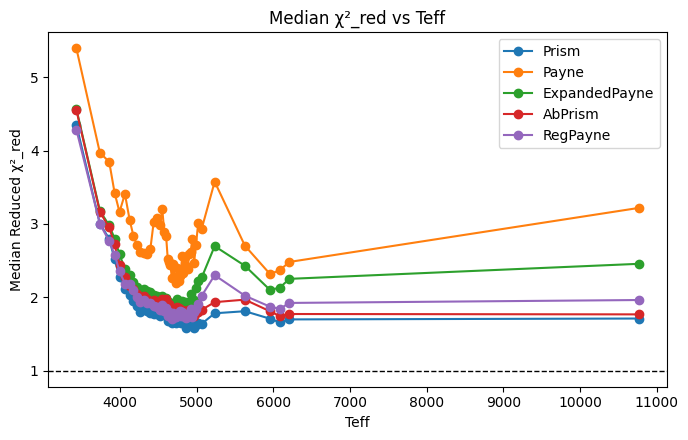

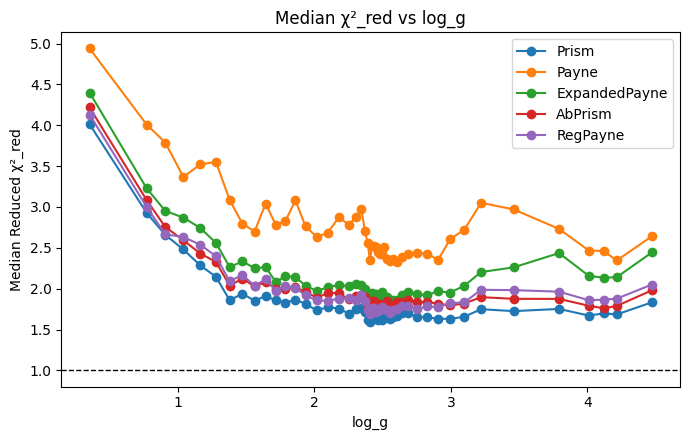

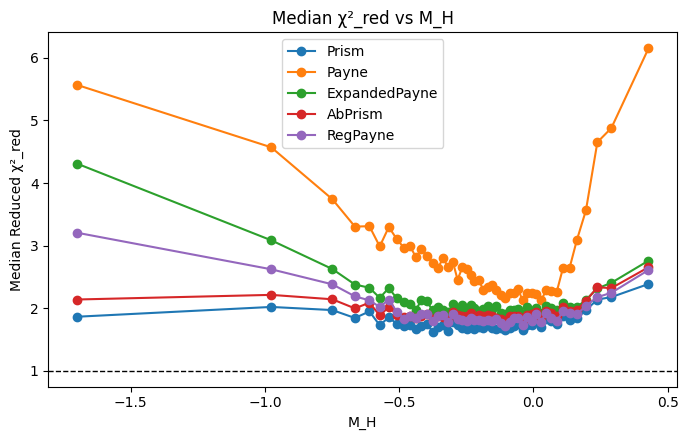

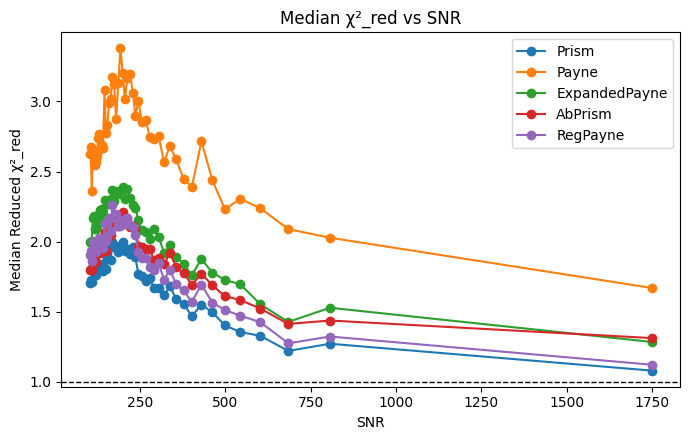

In [6]:

print("\n" + "=" * 60)
print("  TEST 1 — REDUCED CHI-SQUARED")
print("=" * 60)

test_chi2 = reduced_chi_square(
    real_data, gen_data, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=model,
)

test_chi2_P = reduced_chi_square(
    real_data, gen_data_P, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=ThePayne,
)

test_chi2_EP = reduced_chi_square(
    real_data, gen_data_EP[:, :, 0] if len(gen_data_EP.shape) > 2 else gen_data_EP,
    real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=ExpandedPayne,
)

test_chi2_AbPrism = reduced_chi_square(
    real_data, gen_data_AbPrism[:, :, 0] if len(gen_data_AbPrism.shape) > 2 else gen_data_AbPrism,
    real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=base_AbPrism,
)

test_chi2_RP = reduced_chi_square(
    real_data, gen_data_RP, real_data_ivar,
    tf.constant(test_labels, dtype=tf.float32),
    tf.constant(test_label_err, dtype=tf.float32),
    model_obj=reg_Payne,
)

# ── Print summary ──
for name, chi2 in [("Prism", test_chi2), ("Payne", test_chi2_P),
                    ("ExpandedPayne", test_chi2_EP), ("AbPrism", test_chi2_AbPrism),
                    ("RegPayne", test_chi2_RP)]:
    print(f"\n{name}:")
    print(f"  Mean   = {chi2.mean():.3f}")
    print(f"  Median = {np.median(chi2):.3f}")
    print(f"  95th % = {np.percentile(chi2, 95):.3f}")


# ── Binned plots ──
def quantile_bins(x, min_per_bin=200):
    n_bins = max(5, len(x) // min_per_bin)
    return np.quantile(x, np.linspace(0, 1, n_bins + 1))


def plot_binned_stat(x, chi2_dict, bins, xlabel, stat='median'):
    """Plot binned statistic for multiple models. chi2_dict = {name: array}."""
    plt.figure(figsize=(7, 4.5))
    for name, y in chi2_dict.items():
        vals, edges, _ = binned_statistic(x[:len(y)], y, statistic=stat, bins=bins)
        count, _, _    = binned_statistic(x[:len(y)], y, statistic='count', bins=bins)
        centres = 0.5 * (edges[:-1] + edges[1:])
        mask    = count > 10
        plt.plot(centres[mask], vals[mask], 'o-', label=name)
    plt.axhline(1.0, ls='--', color='black', lw=1)
    plt.xlabel(xlabel)
    plt.ylabel(f"{stat.capitalize()} Reduced χ²_red")
    plt.title(f"{stat.capitalize()} χ²_red vs {xlabel}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{stat}_chi2_vs_{xlabel}.png")
    plt.show()


# Recover physical labels for binning
teff_idx = config.SELECTED_LABELS.index('TEFF')
logg_idx = config.SELECTED_LABELS.index('LOGG')
mh_idx   = config.SELECTED_LABELS.index('M_H')

teff_phys = test_labels[:len(test_chi2), teff_idx] * STD_TENSOR[teff_idx] + MEAN_TENSOR[teff_idx]
logg_phys = test_labels[:len(test_chi2), logg_idx] * STD_TENSOR[logg_idx] + MEAN_TENSOR[logg_idx]
mh_phys   = test_labels[:len(test_chi2), mh_idx]   * STD_TENSOR[mh_idx]   + MEAN_TENSOR[mh_idx]
snr_phys  = SNR[:len(test_chi2)]

chi2_all = {"Prism": test_chi2, "Payne": test_chi2_P, "ExpandedPayne": test_chi2_EP,
            "AbPrism": test_chi2_AbPrism, "RegPayne": test_chi2_RP}

for xvals, xname in [(teff_phys, "Teff"), (logg_phys, "log_g"),
                      (mh_phys, "M_H"), (snr_phys, "SNR")]:
    bins = quantile_bins(xvals)
    plot_binned_stat(xvals, chi2_all, bins, xname, stat='median')
   # plot_binned_stat(xvals, chi2_all, bins, xname, stat='std')


  TEST 2 — INFORMATION LEAKAGE

  Leakage analysis for Prism:
        FE_H:  forbidden=0.000000  allowed=0.017063  leak_ratio=0.0000
       MG_FE:  forbidden=0.000000  allowed=0.041997  leak_ratio=0.0000
       SI_FE:  forbidden=0.000000  allowed=0.023668  leak_ratio=0.0000
       CA_FE:  forbidden=0.000000  allowed=0.049355  leak_ratio=0.0000
       TI_FE:  forbidden=0.000000  allowed=0.019686  leak_ratio=0.0000
        S_FE:  forbidden=0.000000  allowed=0.030685  leak_ratio=0.0000
       AL_FE:  forbidden=0.000000  allowed=0.028795  leak_ratio=0.0000
       MN_FE:  forbidden=0.000000  allowed=0.018445  leak_ratio=0.0000
       NI_FE:  forbidden=0.000000  allowed=0.009600  leak_ratio=0.0000
       CR_FE:  forbidden=0.000000  allowed=0.007517  leak_ratio=0.0000
        K_FE:  forbidden=0.000000  allowed=0.037114  leak_ratio=0.0000
       NA_FE:  forbidden=0.000000  allowed=0.024512  leak_ratio=0.0000
        V_FE:  forbidden=0.000000  allowed=0.006154  leak_ratio=0.0000
       CO_FE: 

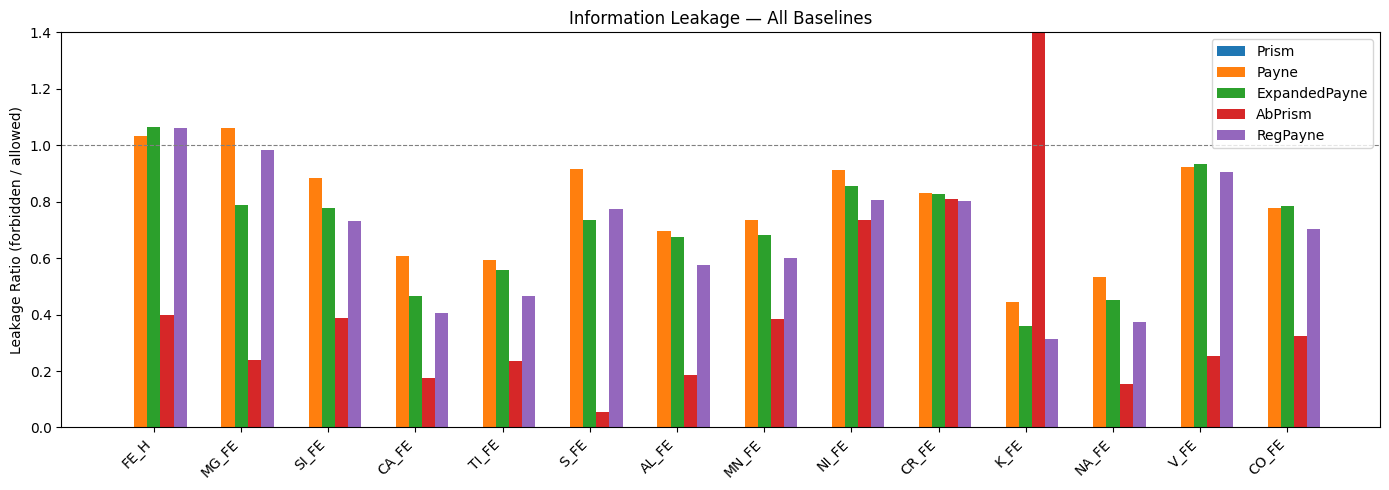

In [7]:
# ============================================================================
#  TEST 2: INFORMATION LEAKAGE (using apogee_mask.npy, full test set)
# ============================================================================
print("\n" + "=" * 60)
print("  TEST 2 — INFORMATION LEAKAGE")
print("=" * 60)

apogee_mask = np.load(apogee_mask_path)  # shape (8575, N_LABELS), convention: 0=allowed, >0=forbidden

LABELS_ORDER = config.SELECTED_LABELS + ['INV_TEFF', 'vbroad', 'C_O_diff', 'LOGPE']
ATOMIC_LABELS = [
    'FE_H', 'MG_FE', 'SI_FE', 'CA_FE', 'TI_FE', 'S_FE',
    'AL_FE', 'MN_FE', 'NI_FE', 'CR_FE', 'K_FE',
    'NA_FE', 'V_FE', 'CO_FE',
]


def compute_leakage(model_obj, model_name, test_lab, mask, epsilon=1e-4):
    """
    For each ATOMIC element, compute the gradient via finite difference,
    then measure how much response 'leaks' into pixels where the element
    has NO spectral line (forbidden region in apogee_mask).

    Uses the full test set (all test stars).
    """
    print(f"\n  Leakage analysis for {model_name}:")

    # Use all test stars — batch through them
    batch_size = 512
    n_stars    = len(test_lab)
    n_batches  = n_stars // batch_size

    results = {}
    for label in ATOMIC_LABELS:
        if label not in LABELS_ORDER:
            continue
        col_idx = LABELS_ORDER.index(label)
        idx_in_selected = config.SELECTED_LABELS.index(label) if label in config.SELECTED_LABELS else None
        if idx_in_selected is None:
            continue

        # apogee_mask convention: 0 = line present (allowed), >0 = no line (forbidden)
        # For leakage, we want pixels where the element is NOT supposed to have influence
        allowed = mask[:, col_idx] > 0  # True where no line expected
        forbidden   = ~allowed             # True where line is expected

        total_grad_forbidden = 0.0
        total_grad_allowed   = 0.0
        count = 0

        for k in range(n_batches):
            s = k * batch_size
            e = (k + 1) * batch_size
            batch = tf.cast(test_lab[s:e], tf.float32)
            grad  = get_gradient(model_obj, batch, idx_in_selected, epsilon=epsilon)
            if len(grad.shape) > 2:
                grad = grad[:, :, 0]
            grad_abs = np.abs(grad.numpy())

            total_grad_forbidden += np.mean(grad_abs[:, forbidden])
            total_grad_allowed   += np.mean(grad_abs[:, allowed]) if np.any(allowed) else 0.0
            count += 1

        avg_forbidden = total_grad_forbidden / max(count, 1)
        avg_allowed   = total_grad_allowed   / max(count, 1)
        ratio = avg_forbidden / avg_allowed if avg_allowed > 0 else float('inf')
        results[label] = {'forbidden': avg_forbidden, 'allowed': avg_allowed, 'ratio': ratio}
        print(f"    {label:>8s}:  forbidden={avg_forbidden:.6f}  allowed={avg_allowed:.6f}  leak_ratio={ratio:.4f}")

    return results


# Run leakage for ALL baselines
leakage_prism = compute_leakage(model,         "Prism",         test_labels, apogee_mask)
leakage_payne = compute_leakage(ThePayne,      "Payne",         test_labels, apogee_mask)
leakage_exp   = compute_leakage(ExpandedPayne, "ExpandedPayne", test_labels, apogee_mask)
leakage_AbPrism   = compute_leakage(base_AbPrism,      "AbPrism",           test_labels, apogee_mask)
leakage_rp    = compute_leakage(reg_Payne,     "RegPayne",      test_labels, apogee_mask)

# ── Leakage bar chart ──
all_leakage = {"Prism": leakage_prism, "Payne": leakage_payne,
               "ExpandedPayne": leakage_exp, "AbPrism": leakage_AbPrism, "RegPayne": leakage_rp}
elements = ATOMIC_LABELS
x_pos    = np.arange(len(elements))
width    = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_ylim(0, 1.4)
for i, (name, leak) in enumerate(all_leakage.items()):
    ratios = [leak[el]['ratio'] if el in leak else 0 for el in elements]
    ax.bar(x_pos + i * width, ratios, width, label=name)
ax.set_xticks(x_pos + 2 * width)
ax.set_xticklabels(elements, rotation=45, ha='right')
ax.set_ylabel("Leakage Ratio (forbidden / allowed)")
ax.set_title("Information Leakage — All Baselines")
ax.legend()
ax.axhline(1.0, ls='--', color='grey', lw=0.8)
fig.tight_layout()
fig.savefig("leakage_comparison.png")
plt.show()


Group                                         Model                 N   Median     Mean      P95      Std
----------------------------------------------------------------------------------------------------
RGB Tip (Teff<4000, logg<1.5)                 Prism               907    2.924    3.485    7.004    2.111
RGB Tip (Teff<4000, logg<1.5)                 Payne               907    3.998    4.791    9.879    3.576
RGB Tip (Teff<4000, logg<1.5)                 ExpandedPayne       907    3.168    3.851    8.020    2.735
RGB Tip (Teff<4000, logg<1.5)                 AbPrism             907    3.071    3.670    7.265    2.246
RGB Tip (Teff<4000, logg<1.5)                 RegPayne            907    2.983    3.539    7.210    2.337
RGB Giants (4000<Teff<5000, 1.5<logg<3.5)     Prism              6485    1.705    1.878    2.993    2.689
RGB Giants (4000<Teff<5000, 1.5<logg<3.5)     Payne              6485    2.549    3.292    7.161    5.797
RGB Giants (4000<Teff<5000, 1.5<logg<3.5)     Expa

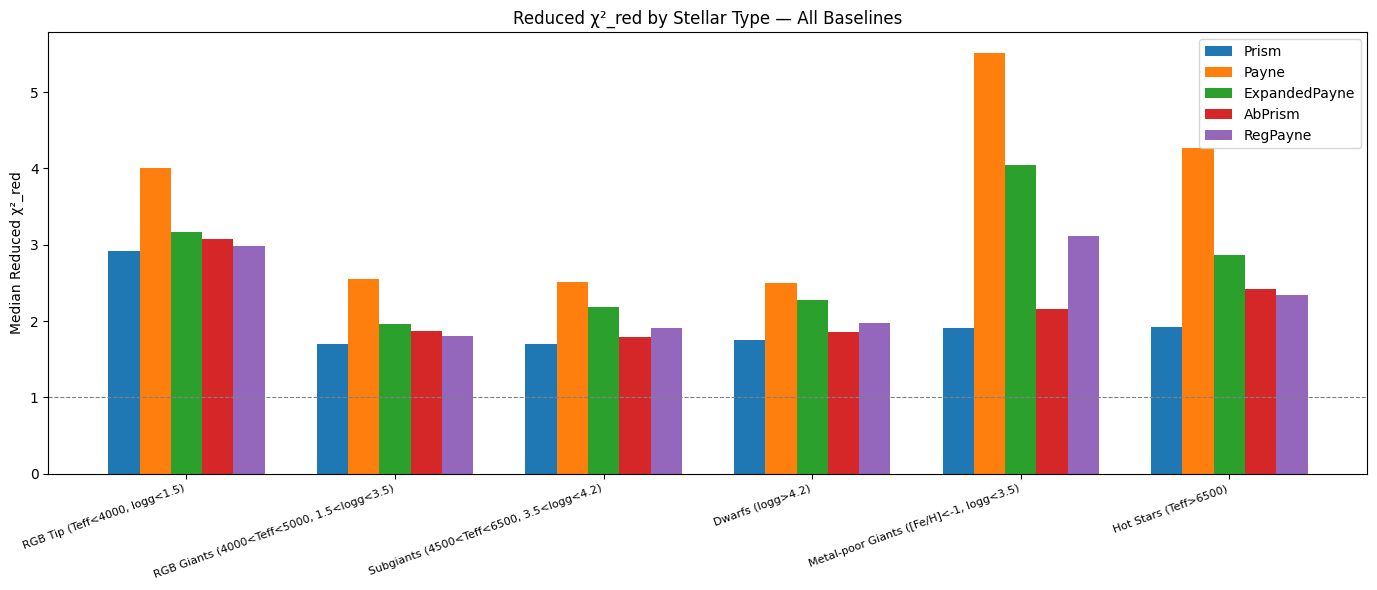

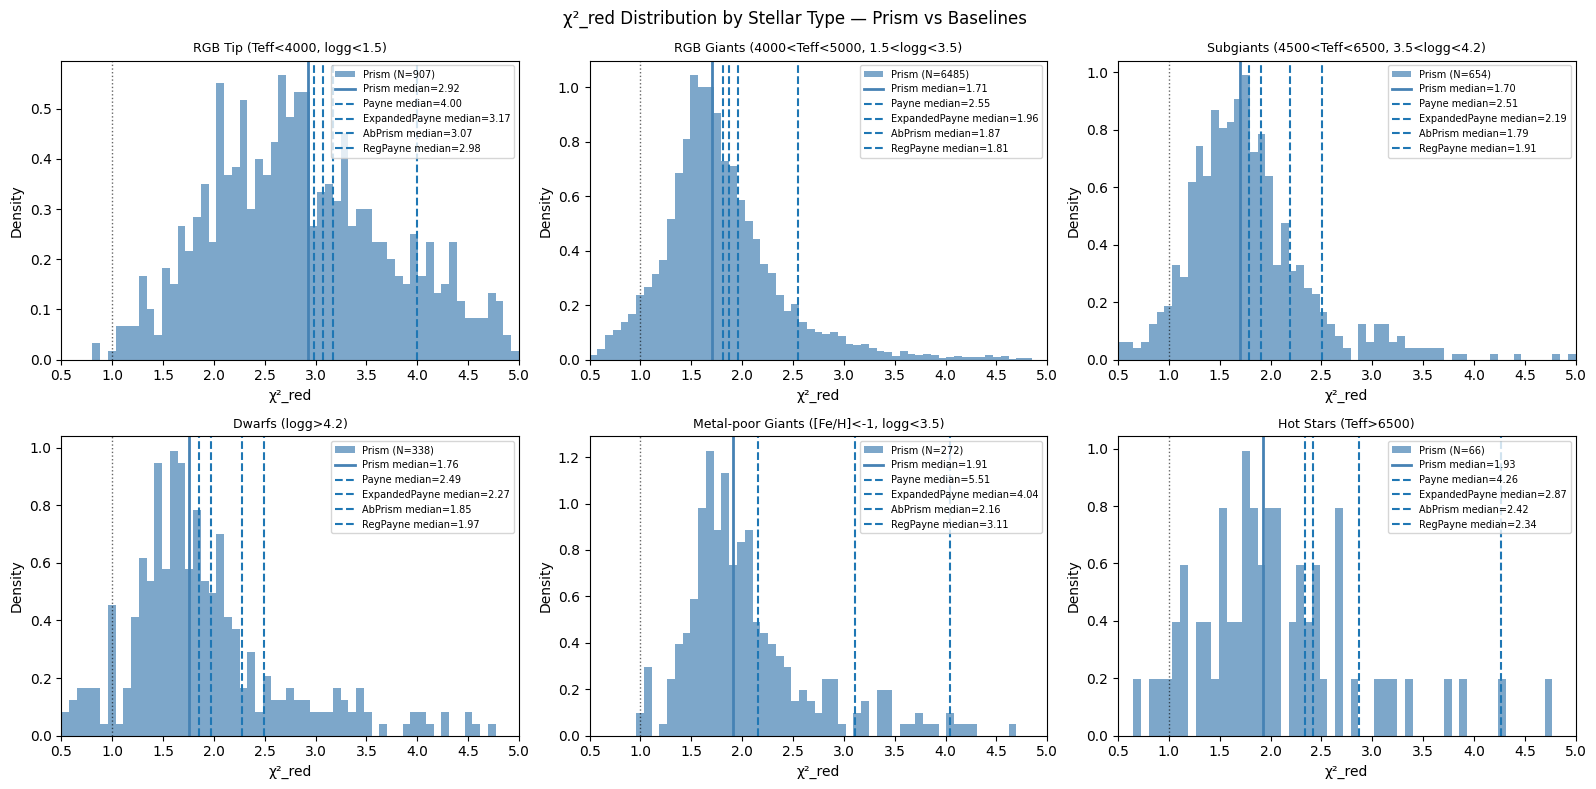


✓ All tests complete.


In [8]:
# ============================================================================
#  TEST 3: REDUCED CHI-SQUARED BY STELLAR TYPE
#
# De-normalise physical labels
teff_idx=config.SELECTED_LABELS.index("TEFF")
logg_idx=config.SELECTED_LABELS.index("LOGG")
feh_idx=config.SELECTED_LABELS.index("M_H")
teff_all = test_labels[:, teff_idx] * STD_TENSOR[teff_idx] + MEAN_TENSOR[teff_idx]
logg_all = test_labels[:, logg_idx] * STD_TENSOR[logg_idx] + MEAN_TENSOR[logg_idx]
feh_all  = test_labels[:, feh_idx]  * STD_TENSOR[feh_idx]  + MEAN_TENSOR[feh_idx]
model_chi2 = {
    "Prism":         test_chi2,
    "Payne":         test_chi2_P,
    "ExpandedPayne": test_chi2_EP,
    "AbPrism":           test_chi2_AbPrism,
    "RegPayne":      test_chi2_RP,
}
# ── Stellar type classification ──────────────────────────────────────────
# RGB tip / luminous giants: coolest, most evolved
mask_rgb_tip    = (teff_all < 4000) & (logg_all < 1.5)

# Standard RGB giants: APOGEE's dominant population
mask_rgb        = (teff_all >= 4000) & (teff_all < 5000) & \
                  (logg_all >= 1.5)  & (logg_all < 3.5)

# Subgiants: between main sequence and giant branch
mask_subgiant   = (teff_all >= 4500) & (teff_all < 6500) & \
                  (logg_all >= 3.5)  & (logg_all < 4.2)

# Main sequence / dwarfs: high logg
mask_dwarf      = (logg_all >= 4.2)

# Metal-poor giants: separate because line strengths are categorically different
mask_metal_poor = (feh_all < -1.0) & (logg_all < 3.5)

# Hot stars: OOD for this model
mask_hot        = teff_all > 6500

stellar_groups = {
    "RGB Tip (Teff<4000, logg<1.5)":           mask_rgb_tip,
    "RGB Giants (4000<Teff<5000, 1.5<logg<3.5)": mask_rgb,
    "Subgiants (4500<Teff<6500, 3.5<logg<4.2)":  mask_subgiant,
    "Dwarfs (logg>4.2)":                          mask_dwarf,
    "Metal-poor Giants ([Fe/H]<-1, logg<3.5)":   mask_metal_poor,
    "Hot Stars (Teff>6500)":                      mask_hot,
}

fig_bar, ax_bar = plt.subplots(figsize=(14, 6))
fig_dist, axes_dist = plt.subplots(
    2, 3, figsize=(16, 8), sharey=False
)
axes_dist = axes_dist.flatten()

x         = np.arange(len(stellar_groups))
bar_width = 0.15
summary_rows = []

for gi, (group_name, gmask) in enumerate(stellar_groups.items()):
    ax = axes_dist[gi]
    
    for mi, (model_name, chi2) in enumerate(model_chi2.items()):
        n    = min(len(chi2), len(gmask))
        gm   = gmask[:n]
        vals = chi2[:n][gm]
        if len(vals) == 0:
            continue

        summary_rows.append({
            'Group':   group_name,
            'Model':   model_name,
            'N_stars': int(np.sum(gm)),
            'Median':  float(np.median(vals)),
            'Mean':    float(np.mean(vals)),
            'P95':     float(np.percentile(vals, 95)),
            'Std':     float(np.std(vals)),
        })

        # Distribution plot — Prism only, with per-model median lines
        if model_name == "Prism":
            ax.hist(
                vals,
                bins=np.linspace(0.5, 5.0, 60),
                density=True,
                alpha=0.7,
                color='steelblue',
                edgecolor='none',
                label=f"Prism (N={len(vals)})"
            )
            ax.axvline(
                np.median(vals),
                color='steelblue',
                lw=2,
                ls='-',
                label=f"Prism median={np.median(vals):.2f}"
            )
        else:
            # Overlay median lines for baselines only (no histogram)
            median_val = np.median(vals)
            ax.axvline(
                median_val,
                lw=1.5,
                ls='--',
                label=f"{model_name} median={median_val:.2f}"
            )

    ax.axvline(1.0, color='black', lw=1.0, ls=':', alpha=0.6)
    ax.set_title(group_name, fontsize=9)
    ax.set_xlabel("χ²_red")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(0.5, 5.0)

fig_dist.suptitle("χ²_red Distribution by Stellar Type — Prism vs Baselines", fontsize=12)
fig_dist.tight_layout()
fig_dist.savefig("chi2_distribution_by_type.png", dpi=150)

# ── Bar chart (median χ²_red, all models) ───────────────────────────────
group_names = list(stellar_groups.keys())
model_names = list(model_chi2.keys())

for mi, mname in enumerate(model_names):
    medians = []
    for gname in group_names:
        match = [r for r in summary_rows
                 if r['Group'] == gname and r['Model'] == mname]
        medians.append(match[0]['Median'] if match else 0)
    ax_bar.bar(x + mi * bar_width, medians, bar_width, label=mname)

ax_bar.set_xticks(x + (len(model_names) - 1) * bar_width / 2)
ax_bar.set_xticklabels(group_names, rotation=20, ha='right', fontsize=8)
ax_bar.set_ylabel("Median Reduced χ²_red")
ax_bar.set_title("Reduced χ²_red by Stellar Type — All Baselines")
ax_bar.axhline(1.0, ls='--', color='grey', lw=0.8)
ax_bar.legend()
fig_bar.tight_layout()
fig_bar.savefig("chi2_by_stellar_type.png", dpi=150)

# ── Summary table ────────────────────────────────────────────────────────
print(f"\n{'Group':<45s} {'Model':<16s} {'N':>6s} "
      f"{'Median':>8s} {'Mean':>8s} {'P95':>8s} {'Std':>8s}")
print("-" * 100)
for r in summary_rows:
    print(f"{r['Group']:<45s} {r['Model']:<16s} {r['N_stars']:>6d} "
          f"{r['Median']:>8.3f} {r['Mean']:>8.3f} {r['P95']:>8.3f} {r['Std']:>8.3f}")

plt.show()
print("\n✓ All tests complete.")

In [9]:
# ── TEST 4: IMPUTED VS NON-IMPUTED LABELS ─────────────────────────────────────
print("\n============================================================")
print("  TEST 4 — REDUCED CHI-SQUARED (IMPUTED VS NATURAL)")
print("============================================================")

# First, construct the bad_mask for the test set
with h5py.File(config.H5_PATH, 'r') as f:
    get_col = lambda k: f['metadata'][k]
    keys    = f['metadata'].dtype.names
    
    raw_values = np.stack([get_col(p)[config.TEST_START:config.TEST_START+len(test_chi2)] for p in config.SELECTED_LABELS], axis=1)
    test_bad_mask   = np.zeros_like(raw_values, dtype=bool)

    for i, label in enumerate(config.SELECTED_LABELS):
        flag_name = f"{label}_FLAG"
        if flag_name in keys:
            flg = get_col(flag_name)[config.TEST_START:config.TEST_START+len(test_chi2)]
            if flg.dtype.names:
                flg = flg[flg.dtype.names[0]]
            if flg.dtype.kind == 'V':
                flg = flg.view('<i4')
            test_bad_mask[:, i] = flg.astype(int) != 0
        elif label in ['TEFF', 'LOGG', 'VMICRO', 'VMACRO', 'VSINI']:
            test_bad_mask[:, i] = raw_values[:, i] < -5000

# For each label and each model
print(f"{'Label':<10s} | {'Model':<15s} | {'N (Natural)':>12s} | {'χ²_red (Nat)':>14s} | {'N (Imputed)':>12s} | {'χ²_red (Imp)':>14s}")
print("-" * 85)

for i, label in enumerate(config.SELECTED_LABELS):
    is_imputed = test_bad_mask[:, i]
    is_natural = ~is_imputed
    
    n_imp = np.sum(is_imputed)
    n_nat = np.sum(is_natural)
    
    if n_imp == 0:
        continue
        
    for model_name, chi2_array in model_chi2.items():
        if len(chi2_array) == 0:
            continue
            
        # calculate median
        med_nat = float(np.median(chi2_array[is_natural])) if n_nat > 0 else np.nan
        med_imp = float(np.median(chi2_array[is_imputed])) if n_imp > 0 else np.nan
        
        if model_name == list(model_chi2.items())[0][0]:
            label_print = label
        else:
            label_print = ""
            
        print(f"{label_print:<10s} | {model_name:<15s} | {n_nat:>12d} | {med_nat:>14.3f} | {n_imp:>12d} | {med_imp:>14.3f}")
    print("-" * 85)
print("\n✓ All tests complete.")



  TEST 4 — REDUCED CHI-SQUARED (IMPUTED VS NATURAL)
Label      | Model           |  N (Natural) |   χ²_red (Nat) |  N (Imputed) |   χ²_red (Imp)
-------------------------------------------------------------------------------------
C_FE       | Prism           |         9675 |          1.764 |           53 |          2.044
           | Payne           |         9675 |          2.717 |           53 |          4.346
           | ExpandedPayne   |         9675 |          2.095 |           53 |          3.083
           | AbPrism         |         9675 |          1.925 |           53 |          2.720
           | RegPayne        |         9675 |          1.914 |           53 |          2.659
-------------------------------------------------------------------------------------
N_FE       | Prism           |         8736 |          1.770 |          992 |          1.726
           | Payne           |         8736 |          2.738 |          992 |          2.623
           | ExpandedPayne   | 